In [1]:
     #import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
      #load dataset
movies = pd.read_csv("/content/movies.csv")
ratings = pd.read_csv("/content/ratings.csv")

df = pd.merge(ratings, movies, on="movieId")

print(df.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [3]:
# data preprocessing
df.dropna(inplace=True)

# Extract year from title
df['year'] = df['title'].str.extract(r'\((\d{4})\)')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df.dropna(inplace=True)

              userId        movieId         rating     timestamp  \
count  100818.000000  100818.000000  100818.000000  1.008180e+05   
mean      326.128717   19412.910552       3.501532  1.205892e+09   
std       182.620110   35490.816132       1.042469  2.162414e+08   
min         1.000000       1.000000       0.500000  8.281246e+08   
25%       177.000000    1199.000000       3.000000  1.018665e+09   
50%       325.000000    2991.000000       3.500000  1.186087e+09   
75%       477.000000    8044.000000       4.000000  1.435994e+09   
max       610.000000  193609.000000       5.000000  1.537799e+09   

                year  
count  100818.000000  
mean     1994.444990  
std        14.361424  
min      1902.000000  
25%      1990.000000  
50%      1997.000000  
75%      2003.000000  
max      2018.000000  


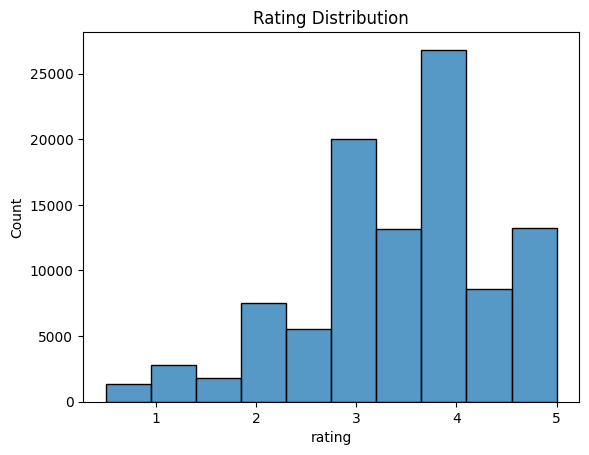

title
Snowflake, the White Gorilla (2011)    5.0
Rain (2001)                            5.0
Justice League: Doom (2012)            5.0
Karlson Returns (1970)                 5.0
Rivers and Tides (2001)                5.0
Bloodsucking Bastards (2015)           5.0
12 Chairs (1976)                       5.0
Raise Your Voice (2004)                5.0
'Salem's Lot (2004)                    5.0
Dylan Moran: Monster (2004)            5.0
Name: rating, dtype: float64


In [4]:
#EDA
print(df.describe())

# Rating Distribution
plt.figure()
sns.histplot(df['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

# Top movies
top_movies = df.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
print(top_movies)

In [5]:
# Encode genres
df['genres'] = df['genres'].str.replace('|', ' ')

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
genre_matrix = cv.fit_transform(df['genres'])

genre_df = pd.DataFrame(genre_matrix.toarray(), columns=cv.get_feature_names_out())

df = pd.concat([df.reset_index(drop=True), genre_df.reset_index(drop=True)], axis=1)

In [6]:
X = df.drop(['rating', 'title', 'genres', 'timestamp'], axis=1)
y = df['rating']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 1.0398164539474268


In [9]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest MSE:", mse_rf)

Random Forest MSE: 0.8963889258083714


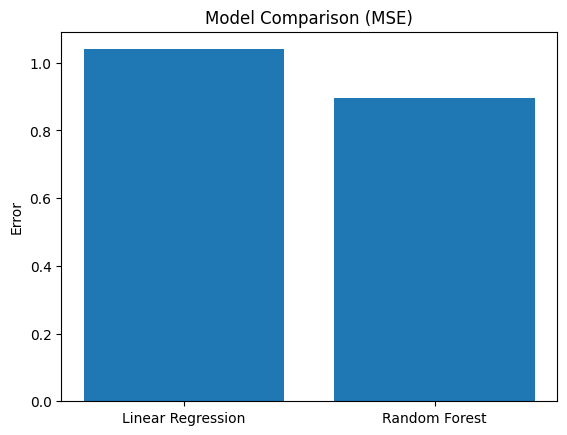

In [10]:
models = ['Linear Regression', 'Random Forest']
errors = [mse_lr, mse_rf]

plt.figure()
plt.bar(models, errors)
plt.title("Model Comparison (MSE)")
plt.ylabel("Error")
plt.show()

In [11]:
#accuracy metric
from sklearn.metrics import r2_score

print("LR R2 Score:", r2_score(y_test, y_pred_lr))
print("RF R2 Score:", r2_score(y_test, y_pred_rf))

LR R2 Score: 0.05030175434579731
RF R2 Score: 0.18129878880806083


In [12]:
# Convert rating into like/dislike
df['like'] = df['rating'].apply(lambda x: 1 if x >= 3.5 else 0)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(['rating', 'like', 'title', 'genres', 'timestamp'], axis=1)
y = df['like']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6404979170799444


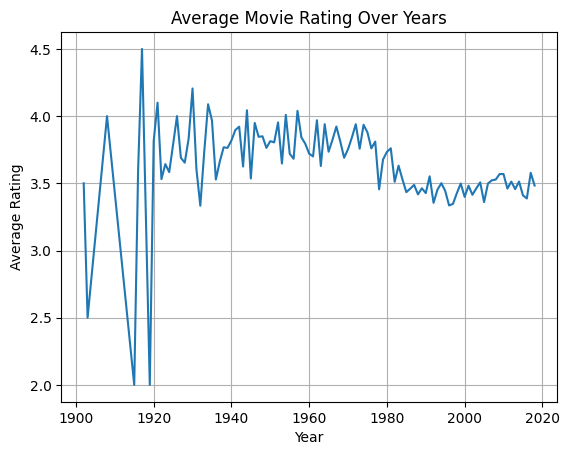

In [13]:
# Average rating per year
year_rating = df.groupby('year')['rating'].mean()

plt.figure()
plt.plot(year_rating.index, year_rating.values)
plt.title("Average Movie Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid()
plt.show()

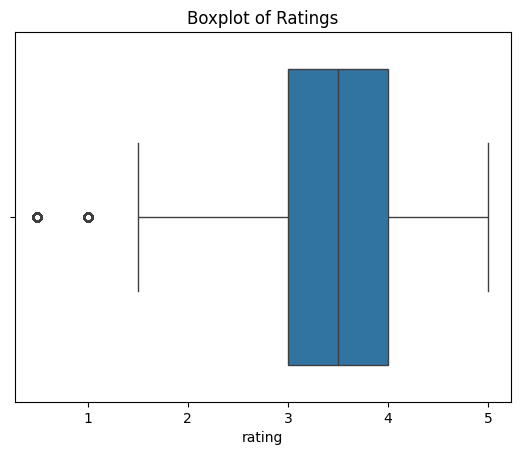

In [14]:
# boxplot
plt.figure()
sns.boxplot(x=df['rating'])
plt.title("Boxplot of Ratings")
plt.show()